# 2026 PDC27: replaying a planetary-defense exercise, method by method

> **This notebook describes a fictional asteroid.** 2026 PDC27 is the
> hypothetical-impact exercise object of the IAA **2027 Planetary Defense
> Conference** (Montreal, May 2027). Quoting JPL CNEOS: *"This is only
> an exercise."*

The exercise's Epoch-1 release ships 52 synthetic observations and a
published impact-probability timeline for 2038-07-10: **0.1%** on July 8,
**16%** when the Rubin precoveries land on July 12, **19%** when the
asteroid enters solar conjunction on July 31. This notebook replays that
knowledge timeline — cumulative fits, night by night, precoveries
injected exactly when the exercise's astronomers received them — and
computes the impact probability **four ways at every step**.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Empyrean-Dynamics/empyrean-scenarios/blob/main/2026_PDC27/main.ipynb)


In [1]:
%pip install -q empyrean==0.10.0


[notice] A new release of pip is available: 26.0 -> 26.2.1
[notice] To update, run: /private/tmp/claude-501/-Users-moeyensj-projects-empyrean/b33ccdba-ac29-4226-b6b5-282f97d1b8e1/scratchpad/venv-final/bin/python3.14 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## 1. The knowledge-timeline replay

Per-observation sigmas (0.1″/0.2″) are the exercise's truth model, so
the weighting honors them instead of survey floors. Each step fits the
observations known on that date and asks for the 2038 impact
probability by linear theory, second-order (Park–Scheeres), AUTO
(the κ-laddered production default), and Monte Carlo (n = 1000,
seeded). **This cell is the slow one (~20 min) — the per-step Monte
Carlo is 12 years × 1000 samples.**


In [2]:
from pathlib import Path

import empyrean
from empyrean import Epochs, ODConfig, Origin, TimeScale, UncertaintyMethod
from empyrean.od.result import SigmaPolicy, WeightingConfig
from empyrean.propagation.config import MonteCarlo

empyrean.initialize()
HERE = Path("2026_PDC27") if Path("2026_PDC27").exists() else Path(".")
obs, _ = empyrean.read_ades(str(HERE / "astrometry.psv"))

PUBLISHED = {"2026-07-08": 0.001, "2026-07-12": 0.16, "2026-07-31": 0.19}
PRECOVERY_NIGHTS = {
    "2026-05-11",
    "2026-05-17",
    "2026-05-23",
    "2026-06-04",
    "2026-06-10",
    "2026-06-16",
}
PRECOVERY_KNOWN = "2026-07-12"
stated_sigmas = ODConfig(
    weighting=WeightingConfig(
        sigma_policy=SigmaPolicy.DEFAULT_ONLY, additional_layers=[]
    )
)
nights = sorted({t[:10] for t in obs.obs_time.to_pylist()})
apparition = [n for n in nights if n not in PRECOVERY_NIGHTS]
end_epoch = Epochs.from_mjd([65625.0], scale=TimeScale.TDB.value)

rows = []
for night in apparition[3:]:
    keep = [
        (night >= PRECOVERY_KNOWN) if t[:10] in PRECOVERY_NIGHTS else t[:10] <= night
        for t in obs.obs_time.to_pylist()
    ]
    arc = obs.apply_mask(keep)
    try:
        fit = empyrean.determine(arc, config=stated_sigmas).single()
    except ValueError:
        continue
    ips = empyrean.compute_impact_probabilities(
        fit.orbit,
        end_epoch,
        [
            UncertaintyMethod.FIRST_ORDER,
            UncertaintyMethod.SECOND_ORDER,
            UncertaintyMethod.AUTO,
            MonteCarlo(n_samples=1000, seed=42),
        ],
        body_filter=[Origin.EARTH],
    )
    bym = {ips.method[i].as_py(): i for i in range(len(ips))}
    a = bym["auto"]
    ip_auto = next(
        v
        for v in (
            ips.ip_agm[a].as_py(),
            ips.ip_second_order[a].as_py(),
            ips.ip_linear[a].as_py(),
        )
        if v is not None
    )
    m = bym["monte_carlo"]
    rows.append(
        {
            "night": night,
            "n": len(arc),
            "kappa": ips.nonlinearity[bym["second_order"]].as_py(),
            "lin": ips.ip_linear[bym["first_order"]].as_py(),
            "snd": ips.ip_second_order[bym["second_order"]].as_py(),
            "auto": ip_auto,
            "mc": ips.ip_mc[m].as_py(),
            "ci": ips.mc_confidence_interval[m].as_py(),
            "published": PUBLISHED.get(night),
        }
    )
    r = rows[-1]
    print(
        f"{r['night']}  n={r['n']:3d}  κ={r['kappa']:6.1f}  "
        f"lin={r['lin']:.5f}  2nd={r['snd']:.5f}  auto={r['auto']:.5f}  "
        f"mc={r['mc']:.3f}±{r['ci']:.3f}"
        + (f"  ← {r['published']} published" if r["published"] else "")
    )

2026-07-01  n=  8  κ=   3.5  lin=0.00010  2nd=0.00003  auto=0.00003  mc=0.000±0.000


2026-07-02  n= 10  κ=   3.9  lin=0.00018  2nd=0.00004  auto=0.00004  mc=0.000±0.000


2026-07-03  n= 12  κ=   4.9  lin=0.00027  2nd=0.00006  auto=0.00006  mc=0.000±0.000


2026-07-04  n= 14  κ=   6.1  lin=0.00039  2nd=0.00006  auto=0.00006  mc=0.000±0.000


2026-07-05  n= 16  κ=  10.1  lin=0.00051  2nd=0.00005  auto=0.00005  mc=0.000±0.000


...

2026-07-13  n= 44  κ=  17.8  lin=0.59705  2nd=0.04132  auto=0.11234  mc=0.165±0.023


2026-07-14  n= 46  κ=  20.8  lin=0.66693  2nd=0.04232  auto=0.11580  mc=0.169±0.023


2026-07-17  n= 48  κ=  53.1  lin=0.93359  2nd=0.04180  auto=0.12866  mc=0.175±0.024


2026-07-24  n= 50  κ=  35.9  lin=0.86094  2nd=0.04504  auto=0.13212  mc=0.183±0.024


2026-07-31  n= 52  κ=  36.1  lin=0.87715  2nd=0.04775  auto=0.13638  mc=0.190±0.024  ← 0.19 published


## 2. The figure: one probability, four answers

Impact probability for 2038-07-10 on a log axis, one line per
uncertainty method, the Monte Carlo 95% band shaded, and the
exercise's published checkpoints as reference diamonds. Where the
lines sit together, linear theory was enough; where they fan apart,
you are watching nonlinearity arrive — κ reaches ~50 by the end,
and only the sampling method tracks the published values.


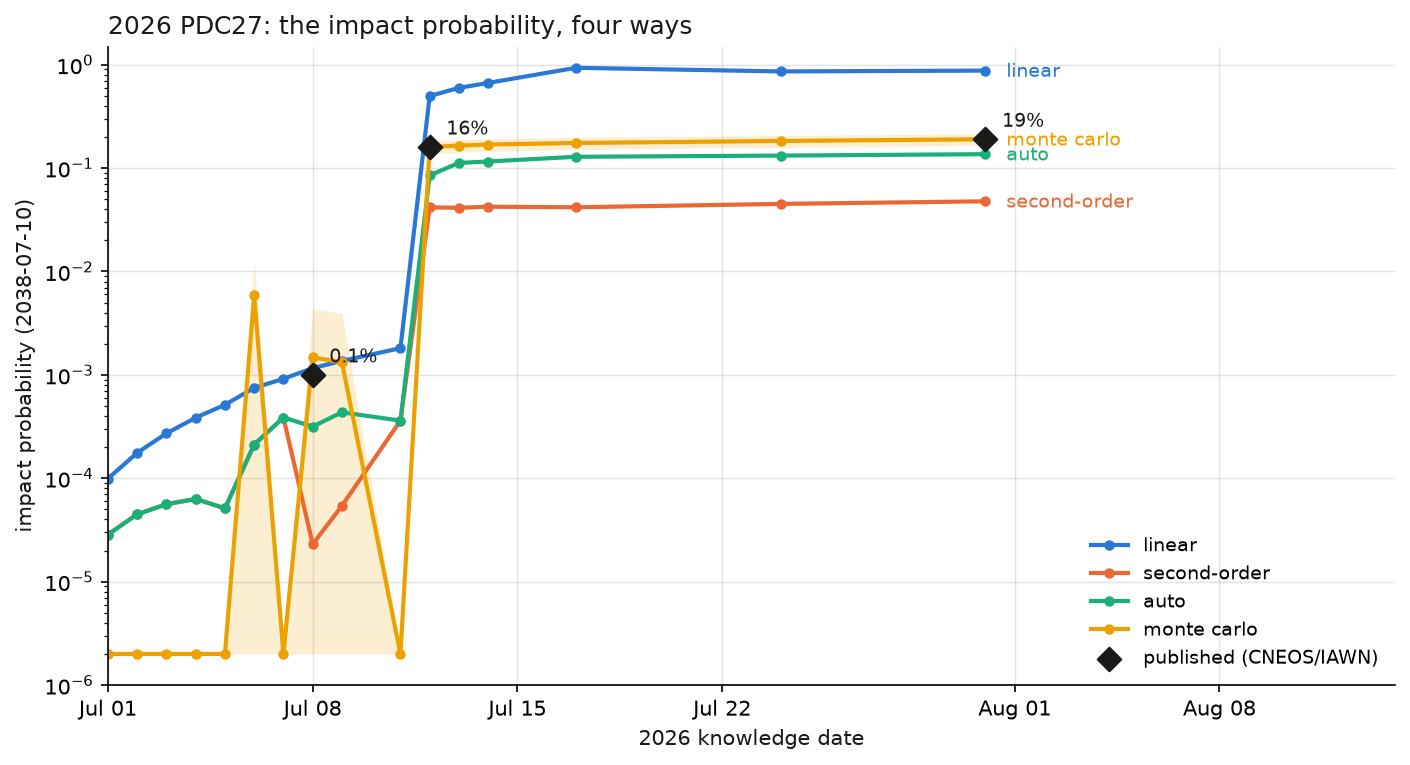

In [3]:
from datetime import datetime

import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Categorical palette (validated: CVD-safe order, light surface)
COLORS = {
    "linear": "#2a78d6",
    "second-order": "#eb6834",
    "auto": "#1baf7a",
    "monte carlo": "#eda100",
}
INK, MUTED = "#1a1a19", "#6b6a63"

dates = [datetime.fromisoformat(r["night"]) for r in rows]
floor = 2e-6  # keep zero-impact MC steps on the log axis
series = {
    "linear": [max(r["lin"], floor) for r in rows],
    "second-order": [max(r["snd"], floor) for r in rows],
    "auto": [max(r["auto"], floor) for r in rows],
    "monte carlo": [max(r["mc"], floor) for r in rows],
}
fig, ax = plt.subplots(figsize=(9.5, 5.2), dpi=150)
for name, ys in series.items():
    ax.plot(
        dates, ys, color=COLORS[name], linewidth=2, marker="o", markersize=4, label=name
    )
mc_lo = [max(r["mc"] - r["ci"], floor) for r in rows]
mc_hi = [max(r["mc"] + r["ci"], floor) for r in rows]
ax.fill_between(
    dates, mc_lo, mc_hi, color=COLORS["monte carlo"], alpha=0.18, linewidth=0
)
pub = [(d, r["published"]) for d, r in zip(dates, rows) if r["published"]]
ax.scatter(
    [d for d, _ in pub],
    [p for _, p in pub],
    marker="D",
    s=64,
    color=INK,
    zorder=5,
    label="published (CNEOS/IAWN)",
)
for d, p in pub:
    ax.annotate(
        f"{p:.0%}" if p >= 0.01 else f"{p:.1%}",
        (d, p),
        textcoords="offset points",
        xytext=(8, 6),
        fontsize=9,
        color=INK,
    )
for name, ys in series.items():  # direct labels at line ends
    ax.annotate(
        name,
        (dates[-1], ys[-1]),
        textcoords="offset points",
        xytext=(10, -3),
        fontsize=9,
        color=COLORS[name],
    )
ax.set_yscale("log")
ax.set_ylim(1e-6, 1.5)
ax.set_xlim(dates[0], dates[-1] + (dates[-1] - dates[-3]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_xlabel("2026 knowledge date", color=INK)
ax.set_ylabel("impact probability (2038-07-10)", color=INK)
ax.set_title("2026 PDC27: the impact probability, four ways", color=INK, loc="left")
ax.grid(True, which="major", color=MUTED, alpha=0.18, linewidth=0.7)
ax.legend(loc="lower right", frameon=False, fontsize=9)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(HERE / "ip_evolution.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Reading the figure

- **The precovery jump dominates the curve**: on July 12 the arc
  triples in length and every estimate rises by roughly two orders of
  magnitude; the published 16% checkpoint (IAWN, 2026-07-15) lies on
  the Monte Carlo estimate within its confidence interval.
- **The analytic estimates separate at large κ**, in the expected
  ordering (Park & Scheeres 2006; DeMars, Bishop & Jah 2013): by
  Epoch 1 the linear estimate reads ~88%, the second-order ~5%, and
  the adaptive Gaussian mixture ~14% against the published 19%
  (CNEOS / IAWN, 2026-08-01). κ ≈ 36 quantifies the nonlinearity of
  the twelve-year mapping that produces this spread.
- **The Monte Carlo estimates agree with all three published
  checkpoints** — 0.1% → 16% → 19% — within their 95% binomial
  confidence intervals (method practice per Roa, Farnocchia &
  Chesley 2021).